# P3: Sampling

This protocol covers constructing sets and sampling: windows, reference and control. Residue-level questions (where does a protease cut? which residue is modified?) are never asked over a whole protein. They are asked over short, fixed-length **windows** anchored on candidate sites. And here is the catch that trips up most newcomers: the known positives are only ever a handful of annotated sites, so the **reference** they must be compared against does not exist yet, you have to build it. How you draw those reference windows quietly decides what any downstream model or CPP signature can possibly learn.

> **Key mental model.** A fair comparison needs *fair* reference and control windows. The **test group** (`label=1`) is the set of **test windows** sitting at known **P1 anchors**; the **reference group** (`label=0`) is the set of **reference windows** you sample around them. Draw that reference unfairly (too easy, too similar, or composition-skewed) and the contrast measures your sampling, not the biology. `AAWindowSampler` is the tool that builds this set reproducibly, with anti-leakage and redundancy filters baked in.

This protocol is a **determinant-discovery / prediction** building block at the **residue level**, the companion to *P1: CPP signature* (which works at the **domain level**). Here we manufacture the windowed input that a residue-level CPP run or downstream classifier consumes. For the mechanics of each sampling method, see the `AAWindowSampler` examples; here we focus on the workflow.

**When to use it.** Use this protocol for **residue-level** prediction: the biological unit is a single site, scored over a fixed-length **window** (glossary: *residue level*). Two sub-modes, distinguished only by window parity:

- **between-residues** (even `window_size`): a scissile bond `… P2·P1 │ P1′·P2′ …` (Schechter–Berger), e.g. **protease cleavage**, our running caspase-3 example.
- **single-residue** (odd `window_size`): a site *on* a residue, e.g. a PTM (phosphorylation, glycosylation).

This is distinct from the **domain level** (*P1: CPP signature*, comparison over `jmd_n`/`tmd`/`jmd_c` parts) and the **protein level** (whole-chain). The defining difficulty at the residue level is **reference construction**: positives are a handful of annotated sites, but the negatives must be *manufactured*, and how you draw them (same protein, other proteins, or synthetic) changes what the downstream model learns.

**When *not* to use it.** Skip this protocol when your data is **already windowed** (one fixed-length slice per row with a binary `label`): there is nothing left to sample, so go straight to *P4: Prediction levels*. Skip it too for **domain-level** work (contrast `jmd_n` / `tmd` / `jmd_c` **parts**, see *P1: CPP signature*) and **protein-level** work (the whole chain is the unit of comparison), where no window is sampled.

**Input.** A `df_seq` with one row per **full protein sequence** (`entry` + `sequence`) and a **pos column** (default name `pos`): each cell is a `list[int]` of 1-based **P1 anchors**, the known positive sites on that protein (empty list = no annotated site). This is the upstream format produced by an annotation step (e.g. `AnnotationPreprocessor.to_df_seq`, or your own curation of literature cleavage sites).

> Note: the bundled `aa.load_dataset(name="AA_CASPASE3")` returns sequences that are **already windowed** (one 9-mer per row, with a binary `label`): it is the *output* of a sampling step, not the *input* to one. To demonstrate the sampler we therefore start from full sequences with a `pos` column, which is exactly what `AAWindowSampler` expects.

Rows that carry positives are **substrate** proteins; rows with an empty `pos` cell are **non-substrate** proteins, the latter form the candidate pool for cross-protein sampling.

In [1]:
import aaanalysis as aa
import pandas as pd

aa.options["verbose"] = False
aa.options["random_state"] = 42

# Full-sequence df_seq for caspase-3 cleavage (P1 anchor = the Asp of a D-x-x-D motif).
# Substrate proteins carry 1-based P1 anchors in `pos`; non-substrate proteins have [].
df_seq = pd.DataFrame({
    "entry": ["SUB1", "SUB2", "SUB3", "NEG1", "NEG2", "NEG3"],
    "sequence": [
        "MKTAYIAKQRDEVDSGLAPYKVLNMQATGHIWDETDSARKLMNPQRSTV",
        "GASPMNLKDEVDTAGRWFYHCIKLMNPQRSTVWYDQTDSGKLAANPQRS",
        "MQALDEVDGKLMNPQRSTVWYACDEFGHIKLMNPQRSTVWYAKLM",
        "ACDEFGHIKLMNPQRSTVWYACDEFGHIKLMNPQRSTVWYACDEFGHIK",
        "GHIKLMNPQRSTVWYACDEFGHIKLMNPQRSTVWYGHIKLMNPQRSTVW",
        "WYACDEFGHIKLMNPQRSTVWYKLMNPQRSTVWYACDEFGHIKLMNPQR",
    ],
    "pos": [[14, 36], [9, 35], [9], [], [], []],
})
# `n_pos` = number of annotated P1 anchors (>0 -> substrate, 0 -> non-substrate pool).
aa.display_df(df=df_seq.assign(n_pos=df_seq["pos"].apply(len)), n_rows=6)

,entry,sequence,pos,n_pos
1,SUB1,MKTAYIAKQRDEVDS...TDSARKLMNPQRSTV,"[14, 36]",2
2,SUB2,GASPMNLKDEVDTAG...DQTDSGKLAANPQRS,"[9, 35]",2
3,SUB3,MQALDEVDGKLMNPQ...LMNPQRSTVWYAKLM,[9],1
4,NEG1,ACDEFGHIKLMNPQR...RSTVWYACDEFGHIK,[],0
5,NEG2,GHIKLMNPQRSTVWY...YGHIKLMNPQRSTVW,[],0
6,NEG3,WYACDEFGHIKLMNP...ACDEFGHIKLMNPQR,[],0


**Run.** `AAWindowSampler` exposes four methods, each producing the same `segments`-mode schema: `sample_same_protein` (within-protein hard negatives), `sample_different_protein` (cross-protein unlabeled pool), `sample_synthetic` (composition controls), and `sample_benchmark_set` (a reproducible multi-arm orchestrator). The cells below demonstrate each in turn, assigning a fitting **role** to every sampled window. For per-method parameter details, see the `AAWindowSampler` examples (this protocol stays at the workflow level).

**Role vs. strategy.** Every sampled window carries two orthogonal tags (glossary):

- **role** (`role` column): the *workflow meaning* of the row: `Test`, `Negative`, `Unlabeled`, or `Control`. It answers *"what does this row mean for my training task?"* and you set it.
- **strategy** (`strategy` column): the *sampling provenance*: `same_protein`, `different_protein`, `synthetic:<generator>`, or `motif_matched`. It answers *"which method drew this row?"* and is set automatically.

The two are independent: a `same_protein` window is `Negative` by default, but you could tag it `Unlabeled` if your workflow treats within-protein sites as unlabeled. The three strategies below map onto three reference-construction choices: **same-protein** hard negatives, **different-protein** unlabeled pool, and **synthetic** composition controls.

In [2]:
# Anti-leakage + redundancy filters are configured once, on the sampler instance.
sampler = aa.AAWindowSampler(
    random_state=42,
    max_similarity_to_test=0.8,    # drop sampled windows too similar to any test window (anti-leakage)
    max_similarity_within_ref=0.9, # drop sampled windows too similar to a kept one (redundancy)
    verbose=False,
)

# A test window is the window at a known P1 anchor. window_size=8 is EVEN -> between-residues (cleavage).
# P1-anchor geometry (Schechter-Berger): floor left, ceil right -> right-heavy for even L.
window_size = 8
half_left = (window_size - 1) // 2     # 3
half_right = window_size - half_left   # 5
sp = aa.SequencePreprocessor()
# Test window at P1 anchor 14 on SUB1 -> carries the D-E-V-D caspase motif ('DEVDSGLA').
test_window = sp.get_aa_window(seq=df_seq.loc[0, "sequence"], pos_start=14 - half_left,
                               window_size=8, index1=True)
test_window

'DEVDSGLA'

**The distance band (hard-negative mining).** `sample_same_protein` draws windows from the **same** proteins that contain positives. The `(min_distance_to_pos, max_distance_to_pos)` **distance band** filters candidate anchors by their L1 distance to the *nearest* positive on that protein:

- both `None` (default): every fully-fitting window is admissible, sampled negatives **may overlap** test windows.
- `min_distance_to_pos=window_size`: forces **non-overlapping** hard negatives (no shared residues with a test window).
- add a finite `max_distance_to_pos`: constrains negatives to a *neighbourhood* of positives (local hard negatives).

In [3]:
# same_protein -> within-protein hard negatives (n=12, non-overlapping windows).
df_same = sampler.sample_same_protein(
    df_seq=df_seq, pos_col="pos", n=12, window_size=8,
    min_distance_to_pos=8,   # non-overlapping hard negatives
    role="Negative", seed=42,
)
aa.display_df(df=df_same, n_rows=3)

,entry_win,entry,sequence,window,source_position,label,role,strategy
1,SUB3_21-28,SUB3,MQALDEVDGKLMNPQ...LMNPQRSTVWYAKLM,YACDEFGH,24,0,Negative,same_protein
2,SUB3_33-40,SUB3,MQALDEVDGKLMNPQ...LMNPQRSTVWYAKLM,NPQRSTVW,36,0,Negative,same_protein
3,SUB3_36-43,SUB3,MQALDEVDGKLMNPQ...LMNPQRSTVWYAKLM,RSTVWYAK,39,0,Negative,same_protein


In [4]:
# different_protein -> cross-protein unlabeled pool, drawn only from NEG1/NEG2/NEG3
# (proteins with no positive) -> a natural U set for positive-unlabeled learning.
df_diff = sampler.sample_different_protein(
    df_seq=df_seq, pos_col="pos", n=12, window_size=8,
    role="Unlabeled", seed=42,
)
aa.display_df(df=df_diff, n_rows=3)

,entry_win,entry,sequence,window,source_position,label,role,strategy
1,NEG2_31-38,NEG2,GHIKLMNPQRSTVWY...YGHIKLMNPQRSTVW,STVWYGHI,34,0,Unlabeled,different_protein
2,NEG1_3-10,NEG1,ACDEFGHIKLMNPQR...RSTVWYACDEFGHIK,DEFGHIKL,6,0,Unlabeled,different_protein
3,NEG2_42-49,NEG2,GHIKLMNPQRSTVWY...YGHIKLMNPQRSTVW,NPQRSTVW,45,0,Unlabeled,different_protein


**Synthetic controls.** `sample_synthetic` manufactures windows from a **generator** distribution (no source protein), so rows carry `entry=""`, `source_position=-1`, and `entry_win="synth_{i}"` (per-call counter). Generator shapes:

- built-in strings: `"uniform"`, `"global_freq"` (empirical AA composition of `df_seq`), `"position_specific"`, `"scrambled"`;
- an **AAontology preset** name (e.g. `"alpha_helix"`, `"aa_composition_mp"`): a curated scale normalized into an AA distribution;
- a **list** of preset names for a multiplicative mix (e.g. `["aa_composition_mp", "alpha_helix"]` for a membrane-helix prior);
- a **dict** `{symbol: prob}` for a custom-alphabet frequency table.

Synthetic windows are the null baseline / composition-bias control.

In [5]:
# synthetic -> composition controls; entry_win is a per-call counter (synth_0, synth_1, ...).
df_synth = sampler.sample_synthetic(
    df_seq=df_seq, n=10, window_size=8,
    generator="global_freq", role="Control", seed=42,
)
aa.display_df(df=df_synth, n_rows=2)

,entry_win,entry,sequence,window,source_position,label,role,strategy
1,synth_0,,,SLTRDYSS,-1,0,Control,synthetic:global_freq
2,synth_1,,,DLKWQTLG,-1,0,Control,synthetic:global_freq


**The benchmark-set orchestrator.** `sample_benchmark_set` runs several named **arms** in one call and concatenates them, adding an `arm` column for provenance. Each arm is one ordinary `sample_*` call (`{"method": <strategy>, **kwargs}`); per-arm sub-seeds are derived deterministically from the master `seed`, so the same `seed` reproduces the same benchmark set. It adds no new sampling behaviour, just reproducible multi-arm orchestration.

In [6]:
arms = {
    "hard_neg":  {"method": "same_protein",      "n": 12, "window_size": 8, "min_distance_to_pos": 8},
    "unlabeled": {"method": "different_protein",  "n": 12, "window_size": 8},
    "control":   {"method": "synthetic",          "n": 10, "window_size": 8, "generator": "global_freq"},
}
df_bench = sampler.sample_benchmark_set(df_seq=df_seq, arms=arms, seed=42)
# One reproducible call -> 34 windows across three arms; the counts confirm each per-arm n.
aa.display_df(df=df_bench[["arm", "role", "strategy"]].value_counts().reset_index(), n_rows=3)

,arm,role,strategy,count
1,hard_neg,Negative,same_protein,12
2,unlabeled,Unlabeled,different_protein,12
3,control,Control,synthetic:global_freq,10


**Output.** A few things happened across those four calls, so let's lay the result out and look at it. Notice how the sampled negatives hug the positives along each substrate protein: that is exactly the *fair reference* the *Key mental model* asks for, drawn around the test windows, not from some unrelated corner of the sequence. The panel on the right then tallies the **role** composition of the assembled reference set.

The sampler returns a `segments`-mode DataFrame, one row per window, with the fixed schema `entry_win, entry, sequence, window, source_position, label, role, strategy` (the benchmark set adds `arm`).

- **`entry_win`**: `"<entry>_<start>-<end>"` (1-based inclusive) for protein-sourced windows; identical biological windows across calls share it, so `drop_duplicates(subset="entry_win")` is the natural cross-call dedupe.
- **synthetic** rows use `entry_win="synth_{i}"` (per-call counter), **not** call-stable; dedupe **control windows** on the `window` string instead.

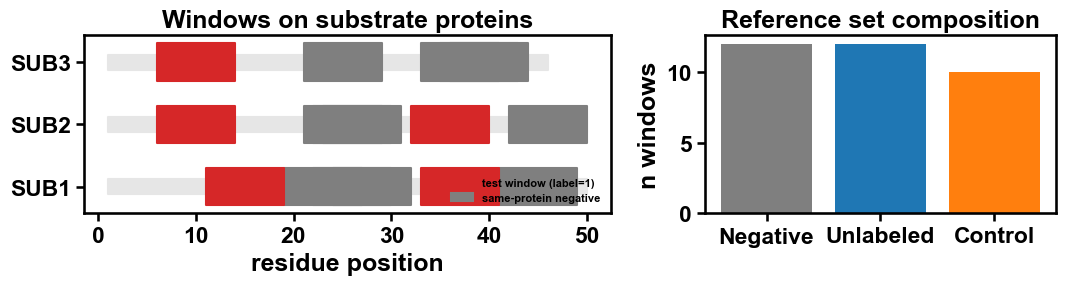

In [7]:
import matplotlib.pyplot as plt

# House style + one consistent colour per role (gray=Negative, blue=Unlabeled, orange=Control, red=Test).
aa.plot_settings()
c_neg, c_unl, c_test, c_ctrl = aa.plot_get_clist(n_colors=4)
role_colors = {"Negative": c_neg, "Unlabeled": c_unl, "Control": c_ctrl}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), gridspec_kw={"width_ratios": [3, 2]})

# Panel A: where windows sit on the three substrate proteins (a fair reference hugs the positives).
ax = axes[0]
substrates = ["SUB1", "SUB2", "SUB3"]
for i, entry in enumerate(substrates):
    row = df_seq[df_seq["entry"] == entry].iloc[0]
    ax.broken_barh([(1, len(row["sequence"]))], (i - 0.12, 0.24), color="0.9", zorder=1)
    for s in df_same.loc[df_same["entry"] == entry, "source_position"]:   # sampled same-protein negatives
        ax.broken_barh([(s - half_left, 8)], (i - 0.30, 0.60), color=c_neg, zorder=2)
    for p in row["pos"]:                                                  # known test windows at P1 anchors
        ax.broken_barh([(p - half_left, 8)], (i - 0.30, 0.60), color=c_test, zorder=3)
ax.set_yticks(range(len(substrates)))
ax.set_yticklabels(substrates)
ax.set_xlabel("residue position")
ax.set_title("Windows on substrate proteins")
handles = [plt.Rectangle((0, 0), 1, 1, color=c_test), plt.Rectangle((0, 0), 1, 1, color=c_neg)]
ax.legend(handles, ["test window (label=1)", "same-protein negative"], loc="lower right", fontsize=8)

# Panel B: role composition of the assembled reference set.
ax = axes[1]
counts = df_bench["role"].value_counts()
ax.bar(counts.index, counts.values, color=[role_colors.get(r, "0.5") for r in counts.index])
ax.set_ylabel("n windows")
ax.set_title("Reference set composition")

plt.tight_layout()

In [8]:
# Dedupe correctly per provenance: entry_win for protein-sourced, window for synthetic.
is_synth = df_bench["strategy"].str.startswith("synthetic")
df_protein = df_bench[~is_synth].drop_duplicates(subset="entry_win")
df_control = df_bench[is_synth].drop_duplicates(subset="window")
df_clean = pd.concat([df_protein, df_control], ignore_index=True)
# df_clean is the assembled window set fed to feature engineering (Protocol 4).
aa.display_df(df=df_clean["role"].value_counts().reset_index(), n_rows=3)

,role,count
1,Negative,12
2,Unlabeled,12
3,Control,10


**How to interpret.** Read the table one row at a time, each row is a single window, and the columns tell you where it came from and what it means for training:

| Column / value | Reading |
| --- | --- |
| one row | one fixed-length **window** anchored at a P1 site |
| `window` | the residue slice the model/CPP actually sees |
| `source_position` | the 1-based P1 anchor on the source protein (`-1` for synthetic) |
| `role = Negative` | within-protein **hard negative** (looks local-similar, not a site) |
| `role = Unlabeled` | cross-protein site of unknown status, the `U` pool for PU-learning |
| `role = Control` | synthetic composition baseline (null) |
| `label` | window-level target (`1` test / `0` reference) for downstream training |

Notice how the set you assemble *is* the **contrast** the downstream residue-level CPP run profiles: test vs. *all* reference, or test vs. a single role (e.g. hard negatives only). Choosing roles **is** choosing the biological question.

**Key takeaways**

- One row = one fixed-length **window**; its **role** (`Test` / `Negative` / `Unlabeled` / `Control`) is the workflow meaning *you* assign, while its **strategy** is the sampling provenance set *for* you.
- Choosing which roles enter the **reference group** (`label=0`) *is* choosing the biological question: the residue-level CPP contrast is only ever as fair as the reference and control windows you draw.
- `entry_win` is the dedupe key for protein-sourced windows across calls; synthetic **control windows** carry a per-call `entry_win`, so dedupe them on the `window` string instead.

**Common mistakes.**

- **Feeding pre-windowed data to the sampler**: `AA_CASPASE3` from `load_dataset` is *already* windowed; the sampler needs **full sequences + a `pos` column**.
- **Forgetting `pos_col`**: without the P1 anchors the sampler cannot identify positives (to exclude them and to drive the anti-leakage filter).
- **Wrong `window_size` parity**: cleavage is between residues (an **even** window); a single-residue PTM needs an **odd** window. Match the biology.
- **Over-sampling a tiny pool**: large `n` with few proteins triggers slow re-draws and a shortfall warning; keep `n` ≈ 10× the number of eligible proteins.
- **Mixing roles without intent**: decide upfront: PU-learning (`Unlabeled`)? hard negatives (`Negative`)? composition control (`Control`)?
- **Naive dedupe**: `drop_duplicates("entry_win")` is right for protein-sourced rows but **wrong for synthetic** (per-call `entry_win`); dedupe controls on `window`.

**Next step.** The clean window set is now the input to *P4: Prediction levels*, where the `window` strings become a `df_seq` whose **parts** are named by the Schechter–Berger convention (`… P2·P1 │ P1′·P2′ …`), built with `SequenceFeature.get_df_parts` and then profiled by `CPP.run` exactly as in *P1: CPP signature* (now at the residue level), or fed as `dict_num` parts to `CPP.run_num`.